In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../Week 1/adult_cleaned.csv")

In [3]:
X = df.drop("income", axis=1)
y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32537, 14)
Target shape: (32537,)


In [4]:
categorical_columns = X.select_dtypes(include="object").columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (32537, 100)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 26029
Testing samples: 6508


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [7]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [8]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[0 1 0 0 0 0 0 0 0 0]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8574


In [10]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Precision: 0.7413
Recall: 0.6269
F1 Score: 0.6793


In [11]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["<=50K", ">50K"]
))

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4940
        >50K       0.74      0.63      0.68      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.78      0.79      6508
weighted avg       0.85      0.86      0.85      6508



In [12]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["<=50K", ">50K"]
))

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4940
        >50K       0.74      0.63      0.68      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.78      0.79      6508
weighted avg       0.85      0.86      0.85      6508



In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4597  343]
 [ 585  983]]


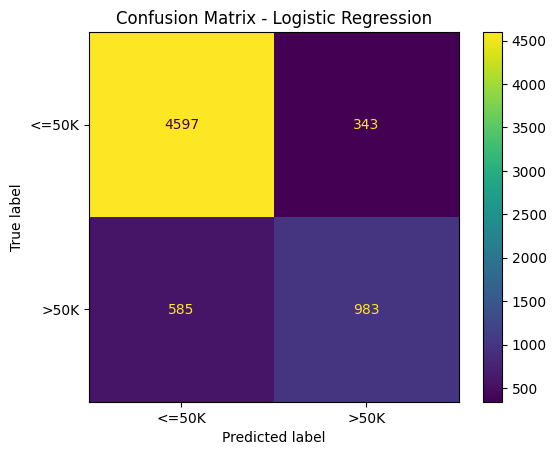

In [14]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [15]:
cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("Mean CV Accuracy:",
      round(cv_scores.mean(), 4))

Cross-validation scores:
[0.84863619 0.84383404 0.85305417 0.85843258 0.84918348]
Mean CV Accuracy: 0.8506


In [16]:
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

top_features = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

print(top_features)

                              Feature  Coefficient  Absolute_Coefficient
3                        capital_gain     2.254348              2.254348
30  marital_status_Married-civ-spouse     1.088873              1.088873
26                education_Preschool    -0.565936              0.565936
2                       education_num     0.547985              0.547985
58                           sex_Male     0.436782              0.436782
5                      hours_per_week     0.367503              0.367503
0                                 age     0.337633              0.337633
96       native_country_United-States    -0.337262              0.337262
53                  relationship_Wife     0.301668              0.301668
10         workclass_Self-emp-not-inc    -0.265013              0.265013
37         occupation_Exec-managerial     0.259895              0.259895
4                        capital_loss     0.259307              0.259307
51             relationship_Own-child    -0.259115 

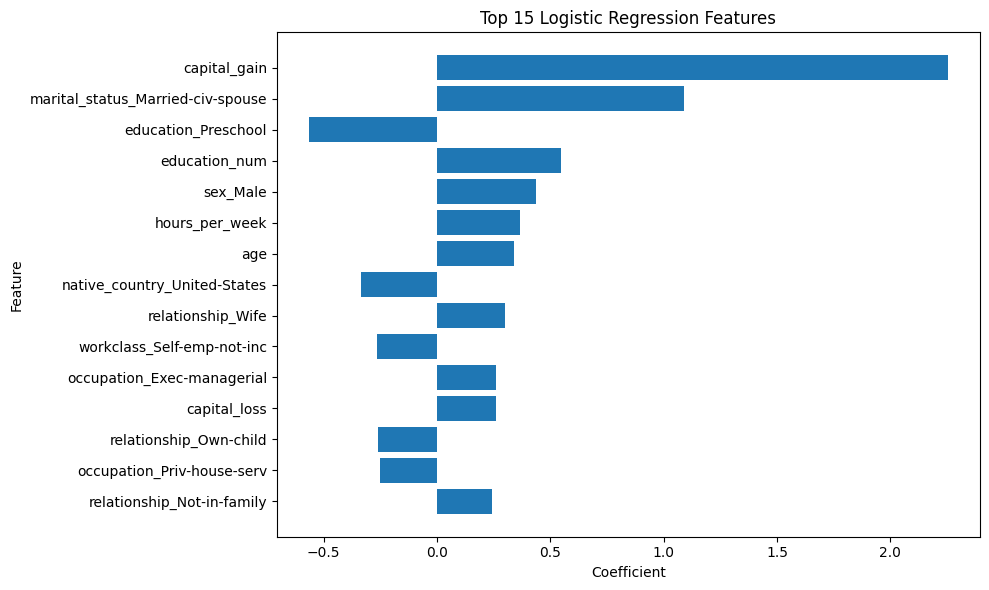

In [17]:
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Coefficient"][::-1]
)

plt.title("Top 15 Logistic Regression Features")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [18]:
print("FINAL MODEL SUMMARY")
print("=" * 40)

print("Model: Logistic Regression")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nEvaluation Metrics")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nCross-Validation")
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("CV Std:", round(cv_scores.std(), 4))

FINAL MODEL SUMMARY
Model: Logistic Regression
Training samples: 26029
Testing samples: 6508

Evaluation Metrics
Accuracy : 0.8574
Precision: 0.7413
Recall   : 0.6269
F1 Score : 0.6793

Cross-Validation
Mean CV Accuracy: 0.8506
CV Std: 0.0049
